# The goal with this analysis is to compare ELISA serostatus to phipseq signal 

In [1]:
import pandas as pd

meta_elisa = pd.read_csv('./LASV_ELISA_Neut_and_PhIP_Seq_result_corrected_w_month_year_filtered_first_tp.csv')

meta_peps = pd.read_csv('./lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')

long = pd.read_csv('./long_091826.csv')

meta_elisa = meta_elisa.drop(columns=['Unnamed: 0'])

In [3]:
cols_to_keep = ['species', 'individual', 'cohort', 'Sample', 'NP_Calc_Conc', 'NP_FINAL_RESULT', 
                'GP_Calc_Conc', 'GP_FINAL_RESULT', 'Serology_Result_Corrected', 'Month_Year']

meta_elisa = meta_elisa[cols_to_keep]

## Filtering to glycoprotein only

In [4]:
long_lasv_gp = long.loc[(long['species'] == 'Mammarenavirus lassaense') & (long['protein_std'] == 'glycoprotein')]

long_lasv_gp = long_lasv_gp.merge(meta_elisa[['individual', 'GP_Calc_Conc', 'GP_FINAL_RESULT', 'Serology_Result_Corrected', 'Month_Year']], on='individual', how='left')

In [5]:
# collapsing number of reactive glycoprotein peptides per individual
gp_individual = (
    long_lasv_gp.groupby('individual')
    .agg(
        gp_serology=('GP_FINAL_RESULT', 'first'), 
        gp_conc = ('GP_Calc_Conc', 'first'), 
        n_gp_peptides=('reactive', 'size'), 
        n_reactive_gp=('reactive', 'sum'), 
        frac_reactive_gp=('reactive', 'mean')
    ).reset_index()
)

gp_individual.head(8)

,individual,gp_serology,gp_conc,n_gp_peptides,n_reactive_gp,frac_reactive_gp
0,C-109-1_5_B3,Negative,1.835048,5,0,0.0
1,C-109-2_5_B5,Negative,1.972705,5,0,0.0
2,C-109-3_4_E7,Positive,23.858109,5,3,0.6
3,C-110-1_2_A5,Negative,2.629727,5,0,0.0
4,C-110-2_3_F8,Positive,3.588056,5,0,0.0
5,C-110-3_2_E6,Negative,2.524546,5,0,0.0
6,C-111-1_2_H8,Positive,3.364582,5,0,0.0
7,C-111-2_3_I5,Positive,9.011087,5,0,0.0


In [6]:
gp_individual['PhIP_gp_positive'] = gp_individual['n_reactive_gp'] > 0

In [7]:
from scipy.stats import fisher_exact

table = pd.crosstab(gp_individual['PhIP_gp_positive'], gp_individual['gp_serology'])

print(table)

odds_ratio, p_value = fisher_exact(table)

print('Odds ratio', odds_ratio)
print('Fisher exact p', p_value)

gp_serology       Negative  Positive
PhIP_gp_positive                    
False                   99       150
True                    49        99
Odds ratio 1.333469387755102
Fisher exact p 0.19888401493087182


In [8]:
from scipy.stats import mannwhitneyu

positive = gp_individual.loc[(gp_individual['gp_serology'] == 'Positive'), 'n_reactive_gp']

negative = gp_individual.loc[(gp_individual['gp_serology'] == 'Negative'), 'n_reactive_gp']

stat, p_value = mannwhitneyu(
    positive, 
    negative, 
    alternative='two-sided'
)

print('Mann-Whitney U', stat)
print('p', p_value)

Mann-Whitney U 20064.5
p 0.0848151115080651


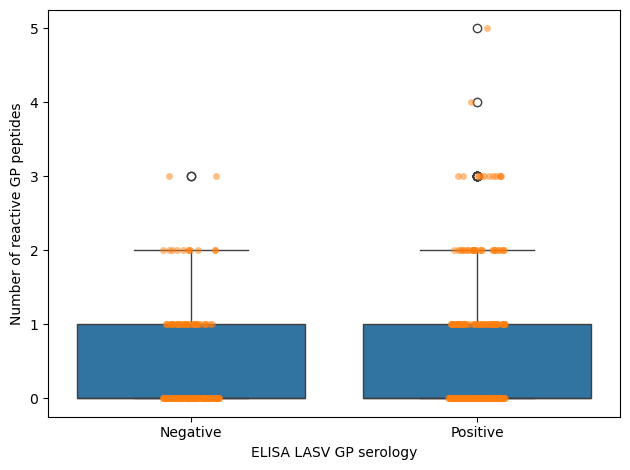

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=gp_individual, 
    x='gp_serology', 
    y='n_reactive_gp'
)

sns.stripplot(
    data=gp_individual, 
    x='gp_serology', 
    y='n_reactive_gp', 
    alpha=0.5
)

plt.xlabel('ELISA LASV GP serology')
plt.ylabel('Number of reactive GP peptides')
plt.tight_layout()
plt.show()

In [10]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    gp_individual['gp_conc'], 
    gp_individual['n_reactive_gp'], 
    nan_policy='omit'
)

print('Spearman rho', rho)
print('p', p_value)

Spearman rho 0.1190062449225651
p 0.017685318980638857


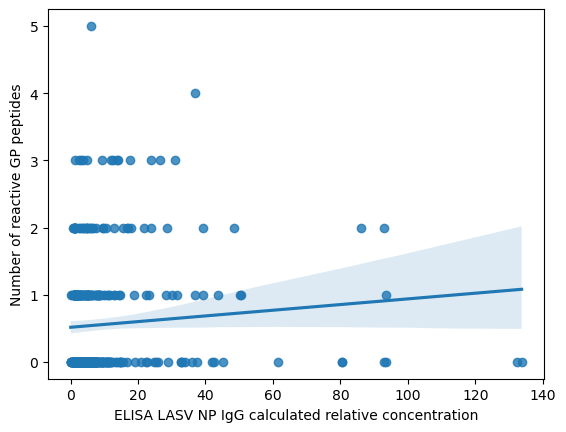

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=gp_individual, 
    x='gp_conc', 
    y='n_reactive_gp'
)

plt.xlabel('ELISA LASV NP IgG calculated relative concentration')
plt.ylabel('Number of reactive GP peptides')
plt.show()

In [12]:
long_lasv_np = long.loc[(long['species'] == 'Mammarenavirus lassaense') & (long['protein_std'] == 'nucleoprotein')]

long_lasv_np = long_lasv_gp.merge(meta_elisa[['individual', 'NP_Calc_Conc', 'NP_FINAL_RESULT', 'Serology_Result_Corrected', 'Month_Year']], on='individual', how='left')

In [13]:
# collapsing number of reactive glycoprotein peptides per individual
np_individual = (
    long_lasv_np.groupby('individual')
    .agg(
        np_serology=('GP_FINAL_RESULT', 'first'), 
        np_conc = ('GP_Calc_Conc', 'first'), 
        n_np_peptides=('reactive', 'size'), 
        n_reactive_np=('reactive', 'sum'), 
        frac_reactive_np=('reactive', 'mean')
    ).reset_index()
)

np_individual.head(8)

,individual,np_serology,np_conc,n_np_peptides,n_reactive_np,frac_reactive_np
0,C-109-1_5_B3,Negative,1.835048,5,0,0.0
1,C-109-2_5_B5,Negative,1.972705,5,0,0.0
2,C-109-3_4_E7,Positive,23.858109,5,3,0.6
3,C-110-1_2_A5,Negative,2.629727,5,0,0.0
4,C-110-2_3_F8,Positive,3.588056,5,0,0.0
5,C-110-3_2_E6,Negative,2.524546,5,0,0.0
6,C-111-1_2_H8,Positive,3.364582,5,0,0.0
7,C-111-2_3_I5,Positive,9.011087,5,0,0.0


In [14]:
np_individual['PhIP_np_positive'] = np_individual['n_reactive_np'] > 0

In [15]:
from scipy.stats import fisher_exact

table = pd.crosstab(np_individual['PhIP_np_positive'], np_individual['np_serology'])

print(table)

odds_ratio, p_value = fisher_exact(table)

print('Odds ratio', odds_ratio)
print('Fisher exact p', p_value)

np_serology       Negative  Positive
PhIP_np_positive                    
False                   99       150
True                    49        99
Odds ratio 1.333469387755102
Fisher exact p 0.19888401493087182


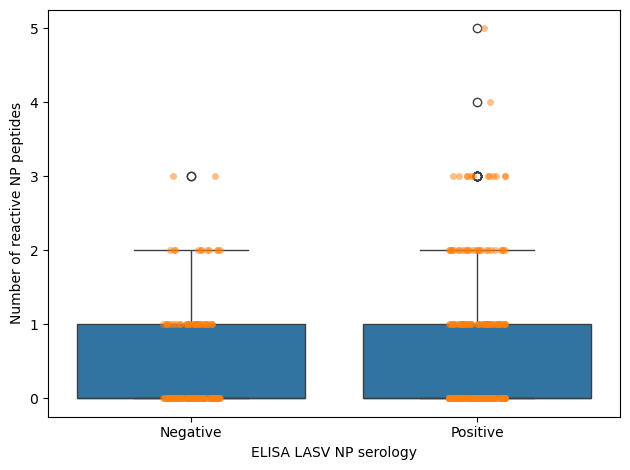

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=np_individual, 
    x='np_serology', 
    y='n_reactive_np'
)

sns.stripplot(
    data=np_individual, 
    x='np_serology', 
    y='n_reactive_np', 
    alpha=0.5
)

plt.xlabel('ELISA LASV NP serology')
plt.ylabel('Number of reactive NP peptides')
plt.tight_layout()
plt.show()

In [17]:
long_lasv = long.loc[(long['species'] == 'Mammarenavirus lassaense')]

long_lasv= long_lasv.merge(meta_elisa[['individual', 'Serology_Result_Corrected', 'Month_Year']], on='individual', how='left')

In [18]:
# collapsing number of reactive glycoprotein peptides per individual
individual = (
    long_lasv.groupby('individual')
    .agg(
        serology=('Serology_Result_Corrected', 'first'), 
        n_peptides=('reactive', 'size'), 
        n_reactive=('reactive', 'sum'), 
        frac_reactive=('reactive', 'mean')
    ).reset_index()
)

individual.head(8)

,individual,serology,n_peptides,n_reactive,frac_reactive
0,C-109-1_5_B3,Negative,76,7,0.092105
1,C-109-2_5_B5,Negative,76,3,0.039474
2,C-109-3_4_E7,Positive,76,10,0.131579
3,C-110-1_2_A5,Positive,76,1,0.013158
4,C-110-2_3_F8,Positive,76,3,0.039474
5,C-110-3_2_E6,Positive,76,6,0.078947
6,C-111-1_2_H8,Positive,76,9,0.118421
7,C-111-2_3_I5,Positive,76,2,0.026316


In [19]:
individual['PhIP_positive'] = individual['n_reactive'] > 0

In [20]:
from scipy.stats import fisher_exact

table = pd.crosstab(individual['PhIP_positive'], individual['serology'])

print(table)

odds_ratio, p_value = fisher_exact(table)

print('Odds ratio', odds_ratio)
print('Fisher exact p', p_value)

serology       Negative  Positive
PhIP_positive                    
False                 1         3
True                 49       344
Odds ratio 2.3401360544217686
Fisher exact p 0.41762315263730077


In [21]:
from scipy.stats import mannwhitneyu

positive = individual.loc[(individual['serology'] == 'Positive'), 'n_reactive']

negative = individual.loc[(individual['serology'] == 'Negative'), 'n_reactive']

stat, p_value = mannwhitneyu(
    positive, 
    negative, 
    alternative='two-sided'
)

print('Mann-Whitney U', stat)
print('p', p_value)

Mann-Whitney U 11624.0
p 9.698789032538046e-05


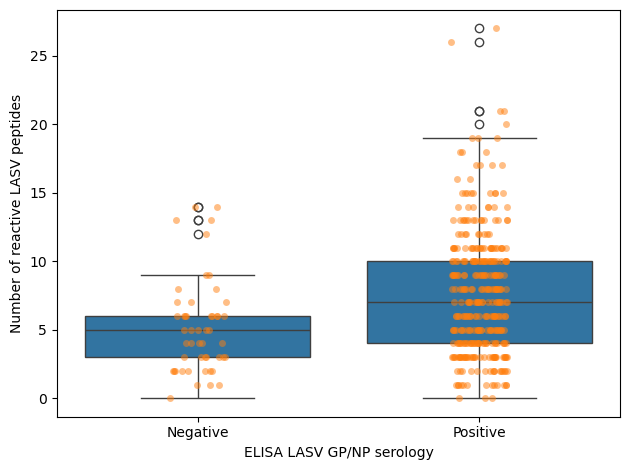

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=individual, 
    x='serology', 
    y='n_reactive'
)

sns.stripplot(
    data=individual, 
    x='serology', 
    y='n_reactive', 
    alpha=0.5
)

plt.xlabel('ELISA LASV GP/NP serology')
plt.ylabel('Number of reactive LASV peptides')
plt.tight_layout()
plt.show()